<!-- Trabalho Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Lista 5 de Exercícios</font>

**ATENÇÃO**: Esta lista de exercícios pode requerer pesquisa complementar. A solução será apresentada no próximo capítulo.

In [12]:
# Imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, statsmodels.api as sm
from scipy.stats import skew, kurtosis

#### Exercício 1: Análise de Distribuição de Receita Mensal

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.

- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.

- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [2]:
# Seed
np.random.seed(10)

# Cria dados de receita
receita = np.random.normal(50000, 8000, 100)

# Cria o dataframe
df = pd.DataFrame({'Receita': receita})

# Visualiza os dados
df.head()

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791



--- Estatísticas Descritivas da Receita ---

Média: 50635.33
Mediana: 50754.95
Desvio Padrão: 7736.32
Assimetria: 0.0136
Curtose: 0.1245


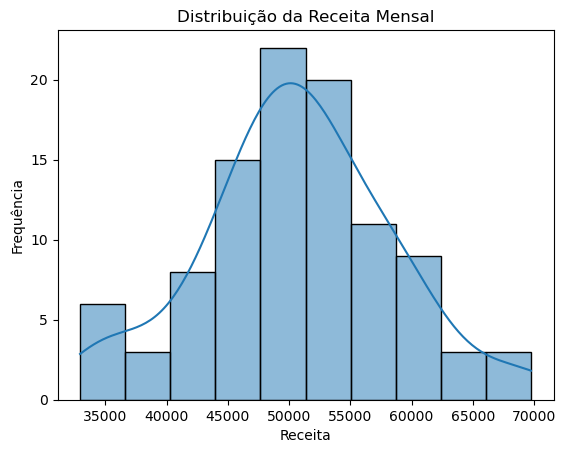

In [17]:
# Estatísticas
media = np.mean(receita)
mediana = np.median(receita)
desvio = np.std(receita)
assimetria = skew(receita)
curtose_val = kurtosis(receita)

print("\n--- Estatísticas Descritivas da Receita ---\n")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio Padrão: {desvio:.2f}")
print(f"Assimetria: {assimetria:.4f}")
print(f"Curtose: {curtose_val:.4f}")

# Visualização
plt.figure()
sns.histplot(receita, kde=True)
plt.title("Distribuição da Receita Mensal")
plt.xlabel("Receita")
plt.ylabel("Frequência")
plt.show()

In [15]:
"A análise da receita mensal mostra que a média (50.635,33) e a mediana (50.754,95) são muito próximas, indicando uma distribuição simétrica dos dados. O desvio padrão de 7.736,32 revela uma variabilidade moderada em torno da média. A assimetria próxima de zero (0,0136) confirma a ausência de viés na distribuição, enquanto a curtose (0,1245) indica um comportamento semelhante ao de uma distribuição normal. Dessa forma, a média é uma medida representativa adequada da tendência central dos dados, e a distribuição pode ser considerada aproximadamente simétrica."

'A análise da receita mensal mostra que a média (50.635,33) e a mediana (50.754,95) são muito próximas, indicando uma distribuição simétrica dos dados. O desvio padrão de 7.736,32 revela uma variabilidade moderada em torno da média. A assimetria próxima de zero (0,0136) confirma a ausência de viés na distribuição, enquanto a curtose (0,1245) indica um comportamento semelhante ao de uma distribuição normal. Dessa forma, a média é uma medida representativa adequada da tendência central dos dados, e a distribuição pode ser considerada aproximadamente simétrica.'

#### Exercício 2: Desempenho por Segmento de Cliente

- Contexto: Uma empresa quer comparar o valor médio gasto por clientes novos e antigos.

- Tarefa: Para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade.

- Resultado esperado: Indique diferenças de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [18]:
# Seed
np.random.seed(5)

# Dataframe
clientes = pd.DataFrame({
    'Grupo': ['Novo']*80 + ['Antigo']*80,
    'Gasto': np.concatenate([np.random.normal(180, 40, 80),
                             np.random.normal(230, 35, 80)])
})

# Visualiza os dados
clientes.sample(10)

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,167.765879
4,Novo,184.384394
27,Novo,165.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,236.535921



--- Estatísticas por Grupo ---

              mean      median        std
Grupo                                    
Antigo  232.921448  231.443713  38.388523
Novo    182.692648  177.481971  38.652415


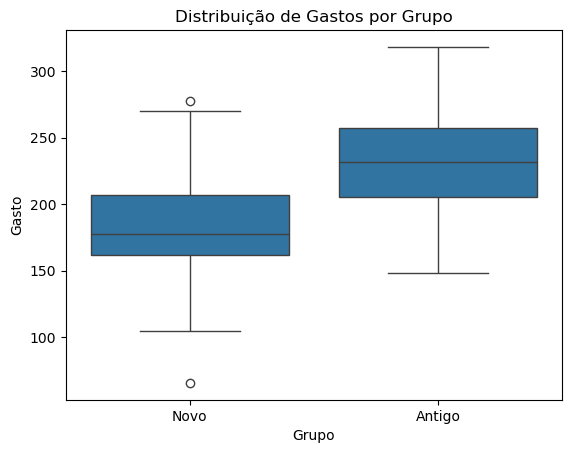

In [19]:
# Solução
# Estatísticas por grupo
stats = clientes.groupby('Grupo')['Gasto'].agg(['mean', 'median', 'std'])
print("\n--- Estatísticas por Grupo ---\n")
print(stats)

# Boxplot
plt.figure()
sns.boxplot(x='Grupo', y='Gasto', data=clientes)
plt.title("Distribuição de Gastos por Grupo")
plt.show()

In [20]:
"A análise mostra que clientes antigos apresentam maior média e mediana de gasto em comparação aos clientes novos, indicando maior valor médio por cliente. O desvio padrão dos clientes novos é ligeiramente maior, sugerindo maior variabilidade no comportamento de consumo. O boxplot evidencia uma sobreposição entre os grupos, o que indica que alguns clientes novos podem atingir níveis de gasto semelhantes aos antigos. No entanto, os clientes antigos demonstram um padrão mais consistente e com maior concentração em valores elevados. Isso sugere que clientes antigos são mais previsíveis e valiosos, enquanto clientes novos apresentam maior variabilidade e potencial de crescimento."

'A análise mostra que clientes antigos apresentam maior média e mediana de gasto em comparação aos clientes novos, indicando maior valor médio por cliente. O desvio padrão dos clientes novos é ligeiramente maior, sugerindo maior variabilidade no comportamento de consumo. O boxplot evidencia uma sobreposição entre os grupos, o que indica que alguns clientes novos podem atingir níveis de gasto semelhantes aos antigos. No entanto, os clientes antigos demonstram um padrão mais consistente e com maior concentração em valores elevados. Isso sugere que clientes antigos são mais previsíveis e valiosos, enquanto clientes novos apresentam maior variabilidade e potencial de crescimento.'

#### Exercício 3: Correlação Entre Horas de Estudo e Nota

- Contexto: Um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos.

- Tarefa: Calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direção da relação.

- Resultado esperado: Descreva se há correlação positiva, negativa ou nula e o que isso significa em termos práticos.

In [21]:
# Seed
np.random.seed(2)

# Dados
horas = np.random.uniform(1, 10, 50)
notas = 5*horas + np.random.normal(0, 5, 50)

# Dataframe
df = pd.DataFrame({'Horas': horas, 'Nota': notas})

# Visualiza os dados
df.head()

,Horas,Nota
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


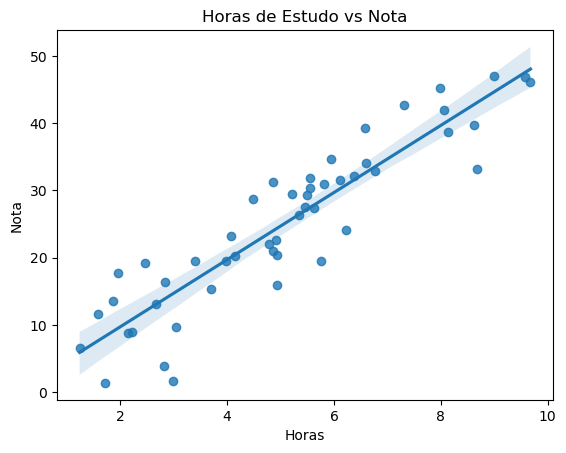

Correlação de Pearson: 0.9149


In [23]:
# Solução

# Gráfico de dispersão com regressão
plt.figure()
sns.regplot(x='Horas', y='Nota', data=df)
plt.title("Horas de Estudo vs Nota")
plt.show()
# Correlação de Pearson
correlacao = df['Horas'].corr(df['Nota'])
print(f"Correlação de Pearson: {correlacao:.4f}")

In [24]:
"A correlação de Pearson encontrada é positiva e forte (próxima de 1), indicando uma relação direta entre horas de estudo e desempenho dos alunos. O gráfico de dispersão com linha de regressão confirma essa tendência crescente, mostrando que alunos que estudam mais tendem a obter notas mais altas. No entanto, a dispersão dos pontos ao redor da linha sugere que outros fatores também influenciam o desempenho. Em termos práticos, o tempo de estudo é um bom preditor das notas, mas não é o único determinante."

'A correlação de Pearson encontrada é positiva e forte (próxima de 1), indicando uma relação direta entre horas de estudo e desempenho dos alunos. O gráfico de dispersão com linha de regressão confirma essa tendência crescente, mostrando que alunos que estudam mais tendem a obter notas mais altas. No entanto, a dispersão dos pontos ao redor da linha sugere que outros fatores também influenciam o desempenho. Em termos práticos, o tempo de estudo é um bom preditor das notas, mas não é o único determinante.'

#### Exercício 4: Variação Semanal de Vendas

- Contexto: O gestor deseja entender como as vendas variam ao longo da semana.

- Tarefa: Simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performance.

- Resultado esperado: Identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [25]:
# Seed
np.random.seed(3)

# Dados
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
vendas = pd.DataFrame({
    'Dia': np.random.choice(dias, 200),
    'Vendas': np.random.normal(1000, 150, 200)
})

# Visualiza os dados
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737



--- Estatísticas por Dia ---

            mean         std
Dia                         
Seg  1008.344683  121.895506
Ter   990.271715  142.264723
Qua  1009.722472  134.496526
Qui  1027.466786  196.069107
Sex  1049.790137  152.085006
Sab  1021.630030  133.611346
Dom  1034.716174  161.899699


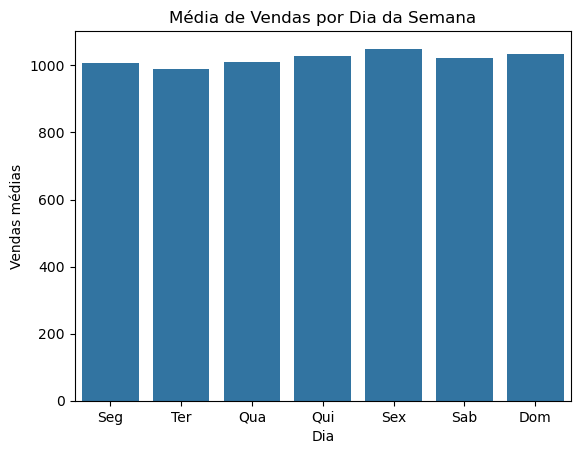

In [26]:
# Solução
# Ordenar dias corretamente
ordem_dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']

# Estatísticas por dia
stats = vendas.groupby('Dia')['Vendas'].agg(['mean', 'std']).reindex(ordem_dias)
print("\n--- Estatísticas por Dia ---\n")
print(stats)

# Gráfico de barras
plt.figure()
sns.barplot(x=stats.index, y=stats['mean'])
plt.title("Média de Vendas por Dia da Semana")
plt.xlabel("Dia")
plt.ylabel("Vendas médias")
plt.show()

In [27]:
"A análise das vendas por dia da semana mostra que a sexta-feira apresenta a maior média de vendas (1049,79), enquanto a terça-feira possui a menor (990,27), indicando um leve aumento no desempenho ao longo da semana. Observa-se uma tendência de crescimento das vendas conforme se aproxima do final de semana. Em relação à variabilidade, a quinta-feira apresenta o maior desvio padrão, sugerindo maior instabilidade nesse dia, enquanto a segunda-feira é mais consistente. Apesar dessas diferenças, as variações entre os dias são relativamente pequenas, indicando que as vendas são globalmente estáveis ao longo da semana, com um leve fortalecimento nos dias finais."

'A análise das vendas por dia da semana mostra que a sexta-feira apresenta a maior média de vendas (1049,79), enquanto a terça-feira possui a menor (990,27), indicando um leve aumento no desempenho ao longo da semana. Observa-se uma tendência de crescimento das vendas conforme se aproxima do final de semana. Em relação à variabilidade, a quinta-feira apresenta o maior desvio padrão, sugerindo maior instabilidade nesse dia, enquanto a segunda-feira é mais consistente. Apesar dessas diferenças, as variações entre os dias são relativamente pequenas, indicando que as vendas são globalmente estáveis ao longo da semana, com um leve fortalecimento nos dias finais.'

#### Exercício 5: Estimativa da Média com Intervalo de Confiança (Statsmodels)

- Contexto: Um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança.

- Tarefa: Calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico.

- Resultado esperado: Apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [28]:
# Seed
np.random.seed(7)

# Conjunto de dados
alturas = np.random.normal(1.75, 0.08, 40)

# Visualiza os dados
alturas

array([1.88524206, 1.71272501, 1.75262561, 1.7826013 , 1.68688616,
       1.75016525, 1.74992877, 1.60962206, 1.83141264, 1.79803988,
       1.69996568, 1.73627614, 1.79042395, 1.72909149, 1.73058007,
       1.63374069, 1.79436642, 1.75991047, 1.77195679, 1.62787804,
       1.88205598, 1.76234684, 1.7190288 , 1.91232578, 1.74636912,
       1.6339457 , 1.71758177, 1.56693479, 1.83395172, 1.71668205,
       1.69059572, 1.83579761, 1.61791395, 1.79283435, 1.58484682,
       1.69702725, 1.65366241, 1.86695805, 1.89129287, 1.7236469 ])

In [29]:
# Solução
# Estatísticas com Statsmodels
descr = sm.stats.DescrStatsW(alturas)

media = descr.mean
ic_inf, ic_sup = descr.tconfint_mean(alpha=0.05)

print("\n--- Estimativa da Altura Média ---\n")
print(f"Média: {media:.4f}")
print(f"IC 95%: ({ic_inf:.4f}, {ic_sup:.4f})")


--- Estimativa da Altura Média ---

Média: 1.7420
IC 95%: (1.7143, 1.7696)


In [30]:
"A altura média estimada dos colaboradores é de 1,7420 metros. O intervalo de confiança de 95% varia entre 1,7143 m e 1,7696 m, indicando que, com base na amostra analisada, há evidências estatísticas de que a média populacional se encontra dentro desse intervalo. A largura relativamente pequena do intervalo sugere uma estimativa precisa, refletindo baixa variabilidade dos dados e um tamanho amostral adequado."

'A altura média estimada dos colaboradores é de 1,7420 metros. O intervalo de confiança de 95% varia entre 1,7143 m e 1,7696 m, indicando que, com base na amostra analisada, há evidências estatísticas de que a média populacional se encontra dentro desse intervalo. A largura relativamente pequena do intervalo sugere uma estimativa precisa, refletindo baixa variabilidade dos dados e um tamanho amostral adequado.'

# Fim